# 1. Librerías

In [1]:
pip install mlxtend

   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 1.4/1.4 MB 11.6 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install plotly

   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   -------------------- ------------------- 5.0/9.6 MB 27.6 MB/s eta 0:00:01
   ---------------------------------------- 9.6/9.6 MB 28.6 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd                   # manipulación de datos 
import numpy as np                    # librería numérica
import matplotlib.pyplot as plt       # librería de graficación
from matplotlib import cm             # librería para el color de barras de color
import datetime as datetime           # librería para manejo de fechas y hora
import seaborn as sns;                # librería para decoración de gráficos
import plotly.express as px           # librería gráfica. Diagramas de ejes paralelos
from sklearn.cluster import KMeans    # librería para agrupamiento
from sklearn import metrics           # librería para usar la métrica silhouette
from mlxtend.frequent_patterns import apriori, association_rules
                                      # librería de reglas de asociación
                                      # pip install mlxtend


# 2. Lectura del archivo

El archivo de este laboratorio contiene informació sobre las líneas de transmisión del sistema eléctrico de potencia colombiano. Es información pública disponible en:

https://paratec.xm.com.co/paratec/SitePages/transmision.aspx?q=lineas

El archivo original se ha procesado previamente para facilitar su lectura.

In [5]:
filename="data-04.csv"
DF=pd.read_csv(filename,sep='\t',parse_dates=['FECHA DE ENTRADA'],dayfirst=True)
DF.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 860 entries, 0 to 859
Data columns (total 20 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   OPERADOR                             860 non-null    object        
 1   LÍNEA                                860 non-null    object        
 2   NIVEL DE TENSIÓN (kV)                860 non-null    float64       
 3   LONGITUD (km)                        860 non-null    float64       
 4   CAPACIDAD TRANSPORTE NOMINAL (A)     860 non-null    float64       
 5   CAPACIDAD TRANSPORTE TÉRMICO (A)     860 non-null    float64       
 6   CAPACIDAD TRANSPORTE EMERGENCIA (A)  860 non-null    float64       
 7   R1 (Ω/km)                            860 non-null    float64       
 8   X1 (Ω/km)                            860 non-null    float64       
 9   B1 (uS/km)                           860 non-null    float64       
 10  R0 (Ω/km)     

In [6]:
DF.head()

,OPERADOR,LÍNEA,NIVEL DE TENSIÓN (kV),LONGITUD (km),CAPACIDAD TRANSPORTE NOMINAL (A),CAPACIDAD TRANSPORTE TÉRMICO (A),CAPACIDAD TRANSPORTE EMERGENCIA (A),R1 (Ω/km),X1 (Ω/km),B1 (uS/km),R0 (Ω/km),X0 (Ω/km),B0 (uS/km),CLASE,CONDUCTOR TIPO,CONDUCTOR CALIBRE,FECHA DE ENTRADA,OBSERVACIONES,ACTIVO COMPARTIDO,ACUERDO
0,ACUEDUCTO METROPOLITANO DE BUCARAMANGA S A E S P,BOSCONIA TBOSCONIA 1 115 KV,115.0,1.04,140.0,140.0,140.0,1.3750,0.5000,3.4375,1.5625,1.9375,1.5625,Str,NaN,0.00,1984-09-01,NaN,No,NaN
1,AIR- E S.A.S. E.S.P.,BARANOA MALAMBO 1 110 kV,110.0,17.70,530.0,580.0,580.0,0.1194,0.4952,3.3400,0.4512,1.4377,2.0600,Str,AAAC,559.5,1985-01-01,NaN,No,NaN
2,AIR- E S.A.S. E.S.P.,CARACOLI CORDIALIDAD 1 110 kV,110.0,14.20,500.0,580.0,570.0,0.1191,0.4718,3.5600,0.4622,1.4739,2.1400,Str,NaN,0.00,2019-02-25,NaN,No,NaN
3,AIR- E S.A.S. E.S.P.,CARACOLI MALAMBO 2 110 kV,110.0,9.50,500.0,580.0,570.0,0.1191,0.4718,3.5600,0.4622,1.4739,2.1400,Str,NaN,0.00,2019-01-27,NaN,No,NaN
4,AIR- E S.A.S. E.S.P.,CARACOLI SILENCIO 1 110 kV,110.0,12.50,691.0,706.0,706.0,0.0736,0.4552,3.6814,0.2417,1.5823,2.1890,Str,NaN,0.00,2019-02-25,NaN,No,NaN


## 2.1. Exploración preliminar del *DataFrame*

Para facilitar el procesamiento de la información, renombramos las columnas y después obtenemos las medidas de tendencia y dispersión:

In [7]:
nombres={
'OPERADOR':'OPERADOR',
'LÍNEA':'LÍNEA',
'NIVEL DE TENSIÓN (kV)':'TENSIÓN',
'LONGITUD (km)':'LONGITUD',
'CAPACIDAD TRANSPORTE NOMINAL (A)':'CAPACIDAD-N',
'CAPACIDAD TRANSPORTE TÉRMICO (A)':'CAPACIDAD-T',
'CAPACIDAD TRANSPORTE EMERGENCIA (A)':'CAPACIDAD-E',
'R1 (Ω/km)':'R1',
'X1 (Ω/km)':'X1',
'B1 (uS/km)':'B1',
'R0 (Ω/km)':'R0',
'X0 (Ω/km)':'X0',
'B0 (uS/km)':'B0',
'CLASE':'CLASE',
'CONDUCTOR TIPO':'TIPO',
'CONDUCTOR CALIBRE':'CALIBRE',
'FECHA DE ENTRADA':'FECHA',
'OBSERVACIONES':'OBSERVACIONES',
'ACTIVO COMPARTIDO':'COMPARTIDO',
'ACUERDO':'ACUERDO'
}
DF.rename(columns=nombres,inplace=True)
DF.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 860 entries, 0 to 859
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   OPERADOR       860 non-null    object        
 1   LÍNEA          860 non-null    object        
 2   TENSIÓN        860 non-null    float64       
 3   LONGITUD       860 non-null    float64       
 4   CAPACIDAD-N    860 non-null    float64       
 5   CAPACIDAD-T    860 non-null    float64       
 6   CAPACIDAD-E    860 non-null    float64       
 7   R1             860 non-null    float64       
 8   X1             860 non-null    float64       
 9   B1             860 non-null    float64       
 10  R0             860 non-null    float64       
 11  X0             860 non-null    float64       
 12  B0             860 non-null    float64       
 13  CLASE          860 non-null    object        
 14  TIPO           129 non-null    object        
 15  CALIBRE        860 non-

## 2.2 Edad de las líneas

A partir de la columna de Fecha de entrada, calculamos la Edad de la línea, medida en días:

In [8]:
Hoy=datetime.datetime.today()
DF['EDAD']=Hoy
Hoy=DF['EDAD']
Ayer=DF['FECHA']
DF['EDAD']=pd.to_datetime(Hoy) - pd.to_datetime(Ayer)
DF['EDAD']=DF['EDAD'].dt.days

In [9]:
DF.head(3)

,OPERADOR,LÍNEA,TENSIÓN,LONGITUD,CAPACIDAD-N,CAPACIDAD-T,CAPACIDAD-E,R1,X1,B1,...,X0,B0,CLASE,TIPO,CALIBRE,FECHA,OBSERVACIONES,COMPARTIDO,ACUERDO,EDAD
0,ACUEDUCTO METROPOLITANO DE BUCARAMANGA S A E S P,BOSCONIA TBOSCONIA 1 115 KV,115.0,1.04,140.0,140.0,140.0,1.3750,0.5000,3.4375,...,1.9375,1.5625,Str,NaN,0.00,1984-09-01,NaN,No,NaN,14914
1,AIR- E S.A.S. E.S.P.,BARANOA MALAMBO 1 110 kV,110.0,17.70,530.0,580.0,580.0,0.1194,0.4952,3.3400,...,1.4377,2.0600,Str,AAAC,559.5,1985-01-01,NaN,No,NaN,14792
2,AIR- E S.A.S. E.S.P.,CARACOLI CORDIALIDAD 1 110 kV,110.0,14.20,500.0,580.0,570.0,0.1191,0.4718,3.5600,...,1.4739,2.1400,Str,NaN,0.00,2019-02-25,NaN,No,NaN,2319


## 2.3. Histogramas

Obtenemos los histogramas de las variables:

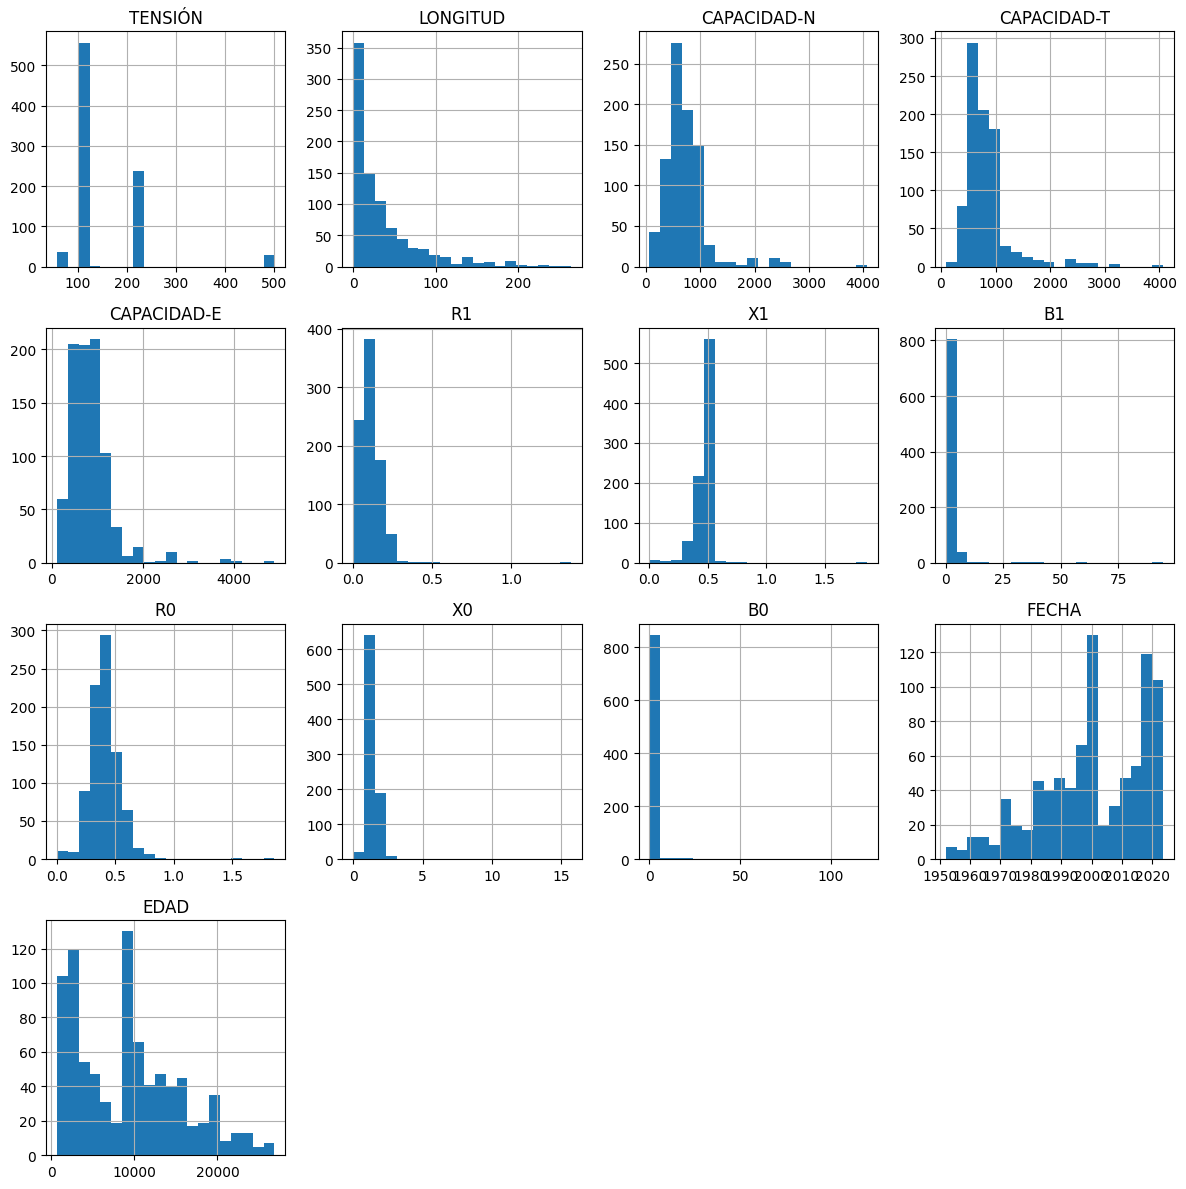

In [10]:
DF.hist(bins=20,figsize=(12,12))
plt.tight_layout()
plt.show()

## 3. Descubrimiento de patrones - clasificación

## 3.1. Diagramas de ejes paralelos

Para explorar las relaciones entre diversas variables, trazamos dos diagramas de ejes paralelos, uno con información 'general' de la linea, y otro con los parámetros de su modelo circuital.

In [11]:
cols=['TENSIÓN','CAPACIDAD-N','LONGITUD','EDAD']
fig = px.parallel_coordinates(DF[cols], color='TENSIÓN',
                             color_continuous_scale=px.colors.diverging.Tealrose)
fig.show()

In [12]:
cols=['R0','R1','X0','X1','B0','B1']
fig = px.parallel_coordinates(DF[DF['R0']<1.0][cols], color='R0',
                             color_continuous_scale=px.colors.diverging.Tealrose)
fig.show()

## 3.2. Nubes de puntos

Debido a que la variable Tensión, pese a ser numérica y contínua toma unos pocos valores, puede considerarse como una variable ordinal. Por esa razón, la hemos empleado para definir el color en las siguientes nubes de puntos, en las que se observa la aparición de algunos patrones.

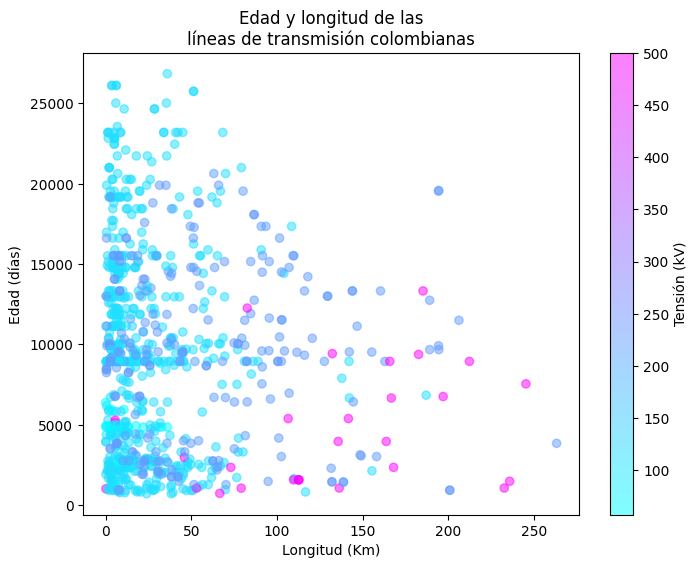

In [13]:
plt.figure(figsize=(8,6))
plt.scatter(DF['LONGITUD'],DF['EDAD'],alpha=0.5,c=DF['TENSIÓN'],cmap=cm.cool)
cbar=plt.colorbar(label='Tensión (kV)')
plt.title('Edad y longitud de las\nlíneas de transmisión colombianas')
plt.xlabel("Longitud (Km)")
plt.ylabel("Edad (días)")
plt.show()

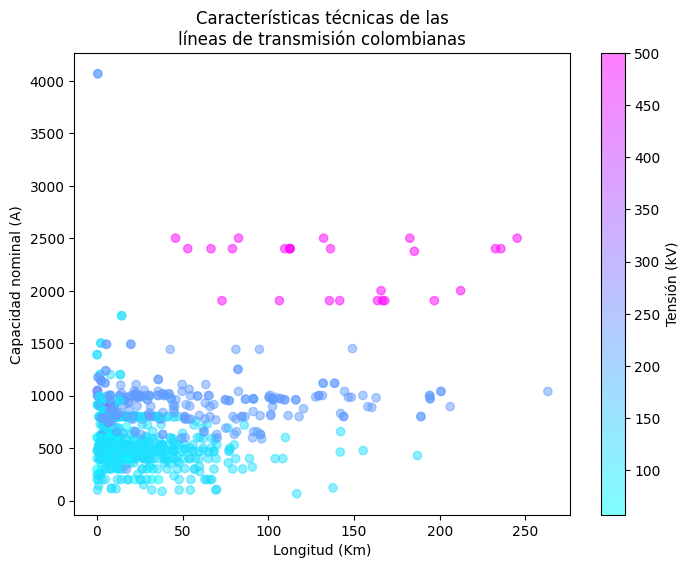

In [14]:
plt.figure(figsize=(8,6))
plt.scatter(DF['LONGITUD'],DF['CAPACIDAD-N'],alpha=0.5,c=DF['TENSIÓN'],cmap=cm.cool)
cbar=plt.colorbar(label='Tensión (kV)')
plt.title('Características técnicas de las\nlíneas de transmisión colombianas')
plt.xlabel("Longitud (Km)")
plt.ylabel("Capacidad nominal (A)")
plt.show()

En el extremo superior-izquierdo del diagrama anterior se aprecia un *outlier*. Para identificar de qupe caso de trata, filtramos el *Dataframe*:

In [15]:
DF[DF['CAPACIDAD-N']>3000]

,OPERADOR,LÍNEA,TENSIÓN,LONGITUD,CAPACIDAD-N,CAPACIDAD-T,CAPACIDAD-E,R1,X1,B1,...,X0,B0,CLASE,TIPO,CALIBRE,FECHA,OBSERVACIONES,COMPARTIDO,ACUERDO,EDAD
570,ENEL COLOMBIA SA ESP,GUAVIO SUBT DUCTO GUAVIO 1 230 kV,230.0,0.55,4067.0,4067.0,4880.0,0.015,0.0859,0.0,...,0.3218,0.0,Uso,NaN,0.00,2002-01-31,NaN,No,NaN,8553
571,ENEL COLOMBIA SA ESP,GUAVIO SUBT DUCTO GUAVIO 2 230 kV,230.0,0.53,4067.0,4067.0,4880.0,0.015,0.0859,0.0,...,0.3218,0.0,Uso,NaN,0.00,1980-01-01,NaN,No,NaN,16619


## 3.3. Clasificación por el nivel de tensión

### 3.3.1. Clasificación manual

Debido a que la variable Tensión toma pocos valores, podemos realizar una clasificación basados en su histograma.

Para ello, primero identificamos los valores que toma la variable y luego trazamos el histgrama. Basados en ese gráfico, observamos que podemos construir tres grupos, separados por los valores
* $150V$
* $250V$

array([115. , 110. ,  66. , 230. , 500. , 220. ,  57.5, 138. ])

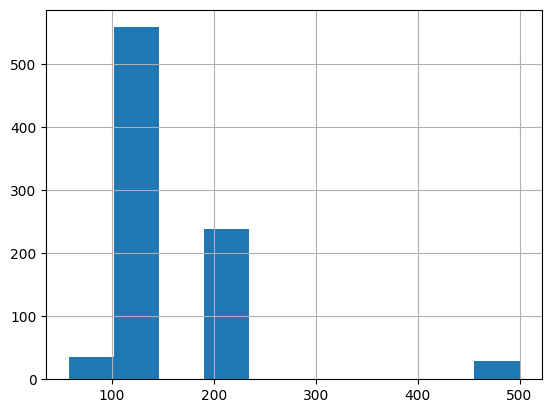

In [16]:
DF['TENSIÓN'].hist()
DF['TENSIÓN'].unique()

Podemos construir una nueva variable categórica, denominada **NIVEL**, que toma tres posibles valores:
* Baja
* Media
* Alta

Al trazar el histograma, destacamos que las categorías están fuertemente desbalanceadas (el npumero de casos para cada categoría es muy diferente).

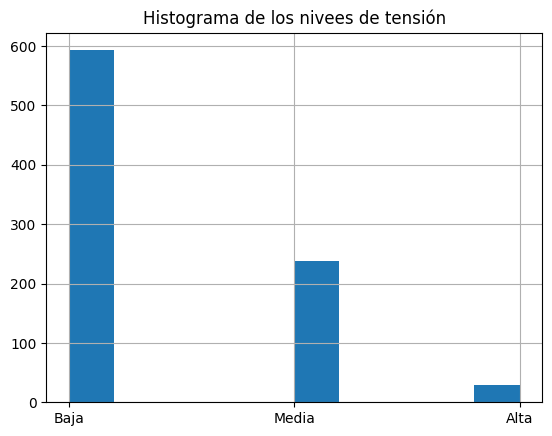

In [17]:
DF['NIVEL']=DF['TENSIÓN'].astype('int64').copy()
nivel=[]
col=DF['TENSIÓN']
tam=col.size
for i in range(0,tam):
    if col[i] < 150:
        nivel.append('Baja')
    else:
        if col[i] < 250:
            nivel.append('Media')
        else:
            nivel.append('Alta')
DF['NIVEL']=nivel
DF['NIVEL'].hist()
plt.title('Histograma de los nivees de tensión')
plt.show()

### 3.3.2. Correlogramas

Con el propósito de destacar la importancia del nivel de tensión, trazamos dos correlogramas. Uno de ellos no utiliza la variable Nivel, y el otro sí.

c:\Users\Claudia\anaconda3\envs\tesina_env\lib\site-packages\seaborn\axisgrid.py:1513: UserWarning:

Ignoring `palette` because no `hue` variable has been assigned.

c:\Users\Claudia\anaconda3\envs\tesina_env\lib\site-packages\seaborn\axisgrid.py:1513: UserWarning:

Ignoring `palette` because no `hue` variable has been assigned.

c:\Users\Claudia\anaconda3\envs\tesina_env\lib\site-packages\seaborn\axisgrid.py:1513: UserWarning:

Ignoring `palette` because no `hue` variable has been assigned.

c:\Users\Claudia\anaconda3\envs\tesina_env\lib\site-packages\seaborn\axisgrid.py:1615: UserWarning:

Ignoring `palette` because no `hue` variable has been assigned.

c:\Users\Claudia\anaconda3\envs\tesina_env\lib\site-packages\seaborn\axisgrid.py:1615: UserWarning:

Ignoring `palette` because no `hue` variable has been assigned.

c:\Users\Claudia\anaconda3\envs\tesina_env\lib\site-packages\seaborn\axisgrid.py:1615: UserWarning:

Ignoring `palette` because no `hue` variable has been assigned.

c:\U

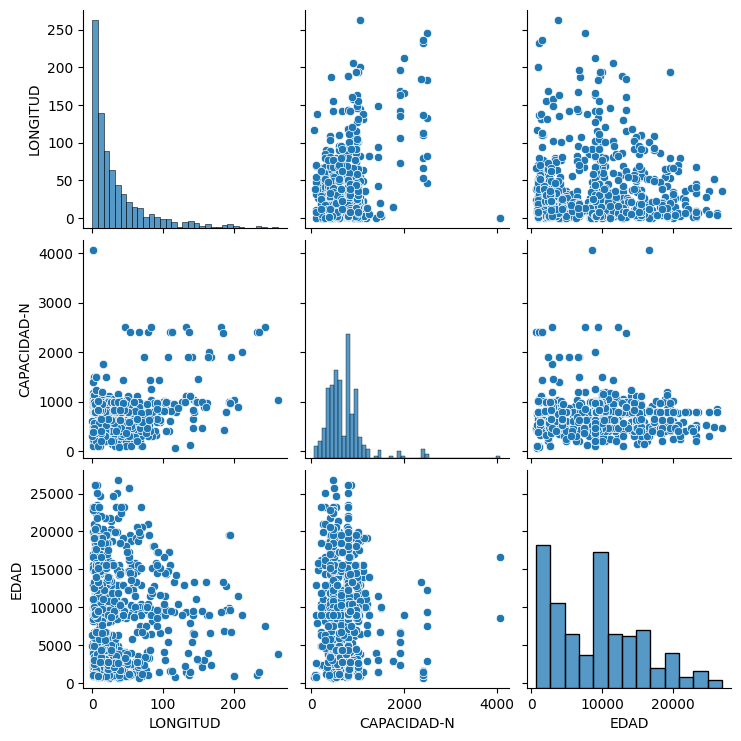

In [18]:
df=DF[['LONGITUD','CAPACIDAD-N','EDAD']]
sns.pairplot(df, kind="scatter", palette="Set2")
plt.show()


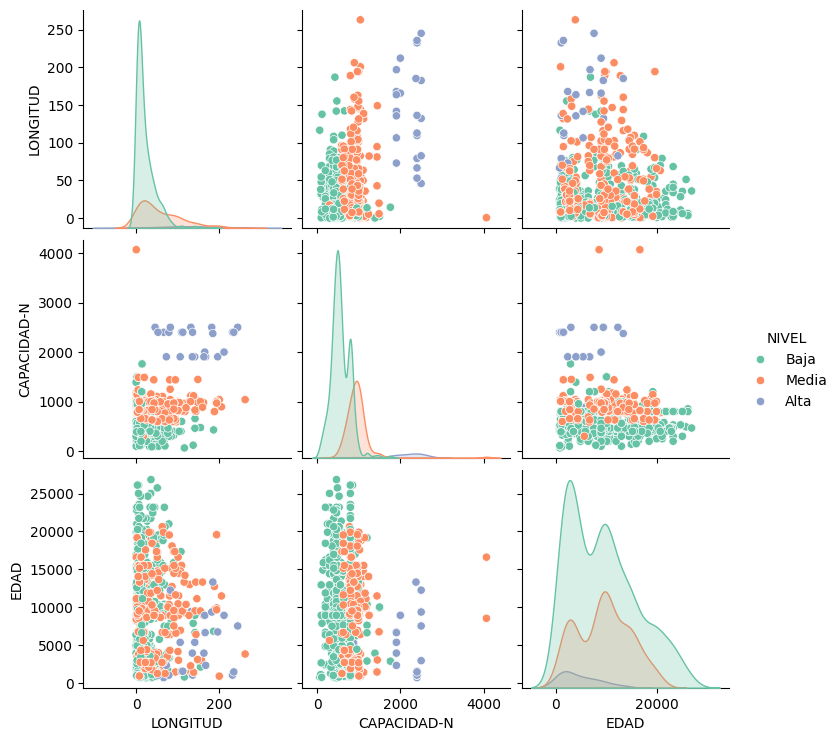

In [19]:
df=DF[['LONGITUD','CAPACIDAD-N','EDAD','NIVEL']]
sns.pairplot(df, kind="scatter", hue='NIVEL', palette="Set2")
plt.show()


### 3.3.3. Agrupamiento *K-means*

En lugar de efectuar una clasificación manual, aplicamos el algoritmo de agrupamiento *K-means* para encontrar tres grupos. El resultado lo almacenamos en una nueva columna del *Dataframe* denominada **CLUSTER**.

In [20]:
X=DF[['TENSIÓN']]
kmeans = KMeans(n_clusters=3).fit(X)
DF['CLUSTER']=kmeans.labels_
DF.head()

,OPERADOR,LÍNEA,TENSIÓN,LONGITUD,CAPACIDAD-N,CAPACIDAD-T,CAPACIDAD-E,R1,X1,B1,...,CLASE,TIPO,CALIBRE,FECHA,OBSERVACIONES,COMPARTIDO,ACUERDO,EDAD,NIVEL,CLUSTER
0,ACUEDUCTO METROPOLITANO DE BUCARAMANGA S A E S P,BOSCONIA TBOSCONIA 1 115 KV,115.0,1.04,140.0,140.0,140.0,1.3750,0.5000,3.4375,...,Str,NaN,0.00,1984-09-01,NaN,No,NaN,14914,Baja,1
1,AIR- E S.A.S. E.S.P.,BARANOA MALAMBO 1 110 kV,110.0,17.70,530.0,580.0,580.0,0.1194,0.4952,3.3400,...,Str,AAAC,559.5,1985-01-01,NaN,No,NaN,14792,Baja,1
2,AIR- E S.A.S. E.S.P.,CARACOLI CORDIALIDAD 1 110 kV,110.0,14.20,500.0,580.0,570.0,0.1191,0.4718,3.5600,...,Str,NaN,0.00,2019-02-25,NaN,No,NaN,2319,Baja,1
3,AIR- E S.A.S. E.S.P.,CARACOLI MALAMBO 2 110 kV,110.0,9.50,500.0,580.0,570.0,0.1191,0.4718,3.5600,...,Str,NaN,0.00,2019-01-27,NaN,No,NaN,2348,Baja,1
4,AIR- E S.A.S. E.S.P.,CARACOLI SILENCIO 1 110 kV,110.0,12.50,691.0,706.0,706.0,0.0736,0.4552,3.6814,...,Str,NaN,0.00,2019-02-25,NaN,No,NaN,2319,Baja,1


Los centros de los clusters están en el arreglo *cluster_centers_*

In [21]:
print(kmeans.cluster_centers_)


[[227.18487395]
 [110.58431703]
 [500.        ]]


Para comparar las dos clasificaciones resultantes, construimos una nube de puntos:

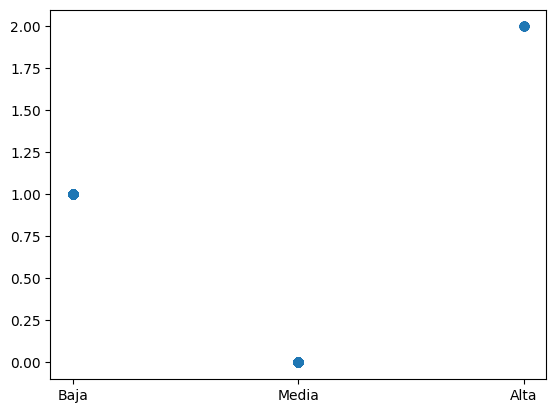

In [22]:
plt.scatter(DF['NIVEL'],DF['CLUSTER'])

### 3.3.4. Número óptimo de grupos

Para explorar cuál sería el npumero óptimo de grupos, aplicamos dos criterios
* La curva de codo
* El coeficiente *silhouette*


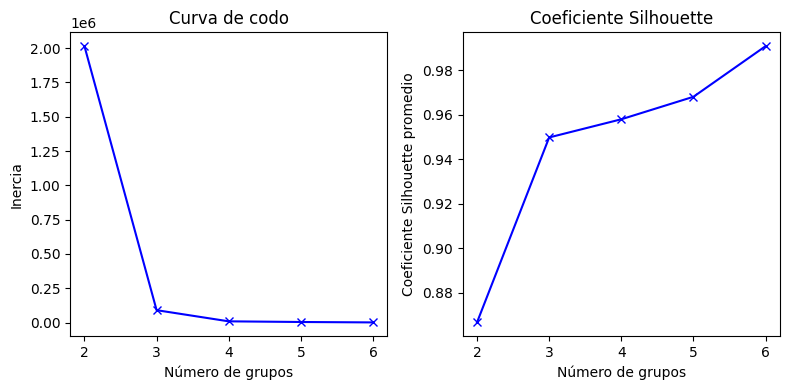

In [23]:
Sum_of_squared_distances = []
silhouette_avg = []
K = range(2,7)
for num_clusters in K :
    # inercia
    kmeans = KMeans(n_clusters=num_clusters)
    kmeans.fit(X)
    Sum_of_squared_distances.append(kmeans.inertia_)
    # coeficiente silhouette 
    cluster_labels = kmeans.labels_
    silhouette_avg.append(metrics.silhouette_score(X, cluster_labels))

fig, axes = plt.subplots(nrows=1, ncols=2,figsize=(8,4))
ax=axes[0]
ax.plot(K,Sum_of_squared_distances,'bx-')
ax.set_xlabel('Número de grupos') 
ax.set_ylabel('Inercia') 
ax.set_title('Curva de codo')
ax=axes[1]
ax.plot(K,silhouette_avg,'bx-')
ax.set_xlabel('Número de grupos') 
ax.set_ylabel('Coeficiente Silhouette promedio') 
ax.set_title('Coeficiente Silhouette')
plt.tight_layout()
plt.show()

### 3.3.5. Agrupamiento por parámetros circuitales

Podemos efectuar un agrupamiento atendiendo a otros criterios; por ejemplo, podemos agrupar según los parámetros circuitales.

Exloremos el número óptimo de clusters:

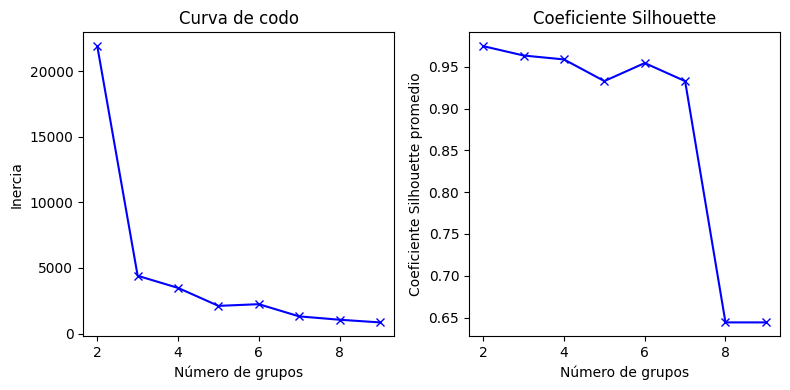

In [24]:
X=DF[['R0','X0','B0','R1','X1','B1',]]
Sum_of_squared_distances = []
silhouette_avg = []
K = range(2,10)
for num_clusters in K :
    # inercia
    kmeans = KMeans(n_clusters=num_clusters)
    kmeans.fit(X)
    Sum_of_squared_distances.append(kmeans.inertia_)
    # coeficiente silhouette 
    cluster_labels = kmeans.labels_
    silhouette_avg.append(metrics.silhouette_score(X, cluster_labels))

fig, axes = plt.subplots(nrows=1, ncols=2,figsize=(8,4))
ax=axes[0]
ax.plot(K,Sum_of_squared_distances,'bx-')
ax.set_xlabel('Número de grupos') 
ax.set_ylabel('Inercia') 
ax.set_title('Curva de codo')
ax=axes[1]
ax.plot(K,silhouette_avg,'bx-')
ax.set_xlabel('Número de grupos') 
ax.set_ylabel('Coeficiente Silhouette promedio') 
ax.set_title('Coeficiente Silhouette')
plt.tight_layout()
plt.show()

Las curvas anteriores sugieren que $K=3$ es un buen número de grupos. El resultado lo almacenamos en la columna **CLUSTER2**, y construimos una nube de puntos para comparar los dos agrupamientos.

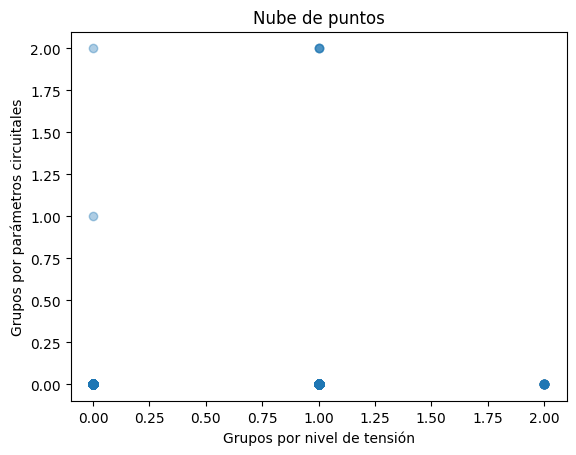

In [25]:
X=DF[['R0','X0','B0','R1','X1','B1',]]
kmeans = KMeans(n_clusters=3).fit(X)
DF['CLUSTER2']=kmeans.labels_

plt.scatter(DF['CLUSTER'],DF['CLUSTER2'],alpha=0.2)
plt.title("Nube de puntos")
plt.xlabel("Grupos por nivel de tensión")
plt.ylabel("Grupos por parámetros circuitales")
plt.show()

Nótese que el nuevo agrupamiento es aún más desbalanceado:

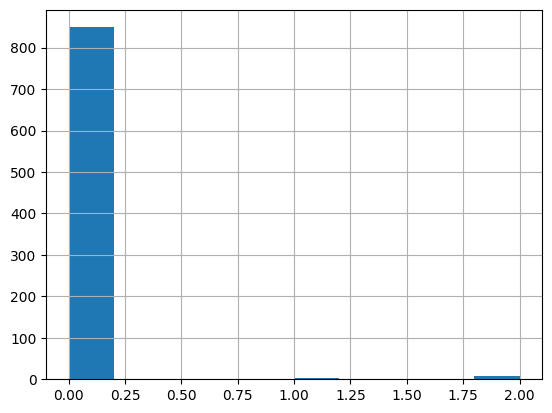

In [26]:
DF['CLUSTER2'].hist()
plt.show()

# 4. Reglas de asociación

## 4.1. Tabla transaccional

Para construir una tabla transaccional a partir de columnas con datos numéricos, definimos la función **DFtransacciones**. Esta función recibe el *Dataframe* con los datos originales, y un *diccionario* de python, en el que cada clave es el nombre de una de las columnas, y el valor un listado en el que se especifican los rangos así:
* el primer elemento contiene la etiqueta
* el segundo elemento contiene el límite inferior del rango
* el tercer elemento contiene el límite superior del rango

La función retorna la tabla transaccional como un nuevo *Dataframe*

In [27]:
def DFtransacciones(DF,variables):
    columnas=[]
    valores=[]
    for variable in variables.keys():
        for rango in variables[variable]:
            etiqueta=variable+'_'+rango[0]
            columnas.append(etiqueta)
            lim_inf =rango[1]
            lim_sup =rango[2]
            serie=[]
            for i in DF.index:
                valor=DF[variable][i]
                if lim_inf <= float(valor) and float(valor) < lim_sup:
                    serie.append(True)
                else:
                    serie.append(False)
            valores.append(serie)
    datos=np.array(valores).transpose()
    DFT=pd.DataFrame(data=datos,columns=columnas)
    return DFT


Construyamos una tabla transaccional con las columnas
* **TENSIÓN**
* **LONGITUD**
* **CAPACIDAD_N**

In [28]:
columnas={'TENSIÓN'    :[['BAJO',0,150] ,['MEDIO',150,400],  ['ALTO',400,1000]],
          'LONGITUD'   :[['CORTA',0,50],['MEDIA',50,100],['LARGA',100,1000]],
          'CAPACIDAD-N':[['BAJO',0,600],['MEDIO',600,1600],['ALTO',1600,5000]]}

DFT=DFtransacciones(DF,columnas)
DFT.head()

,TENSIÓN_BAJO,TENSIÓN_MEDIO,TENSIÓN_ALTO,LONGITUD_CORTA,LONGITUD_MEDIA,LONGITUD_LARGA,CAPACIDAD-N_BAJO,CAPACIDAD-N_MEDIO,CAPACIDAD-N_ALTO
0,True,False,False,True,False,False,True,False,False
1,True,False,False,True,False,False,True,False,False
2,True,False,False,True,False,False,True,False,False
3,True,False,False,True,False,False,True,False,False
4,True,False,False,True,False,False,False,True,False


## 4.2. Reglas de asociación

En este laboratorio usarempos la implementación del algoritmo *apriori* que está disponible en la librería **mlxtend**.

Para ello, primero obtenemos el conjunto de *itemsets* frecuentes, y luego extraemos las reglas

In [31]:
frequent_itemsets = apriori(DFT, min_support=0.1, use_colnames=True)
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(lambda x: len(x))

frequent_itemsets.describe()
#frequent_itemsets

,support,length
count,16.000000,16.0000
mean,0.380160,1.8125
std,0.192130,0.7500
min,0.139535,1.0000
25%,0.243314,1.0000
50%,0.376744,2.0000
75%,0.465116,2.0000
max,0.769767,3.0000


In [32]:
frequent_itemsets

,support,itemsets,length
0,0.689535,(TENSIÓN_BAJO),1
1,0.276744,(TENSIÓN_MEDIO),1
2,0.769767,(LONGITUD_CORTA),1
3,0.139535,(LONGITUD_MEDIA),1
4,0.447674,(CAPACIDAD-N_BAJO),1
5,0.517442,(CAPACIDAD-N_MEDIO),1
6,0.611628,"(TENSIÓN_BAJO, LONGITUD_CORTA)",2
7,0.440698,"(CAPACIDAD-N_BAJO, TENSIÓN_BAJO)",2
8,0.246512,"(CAPACIDAD-N_MEDIO, TENSIÓN_BAJO)",2
9,0.153488,"(LONGITUD_CORTA, TENSIÓN_MEDIO)",2


In [33]:
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.75)
rules["antecedents_length"] = rules["antecedents"].apply(lambda x: len(x))
rules["consequents_length"] = rules["consequents"].apply(lambda x: len(x))
rules.sort_values("confidence",ascending=False)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski,antecedents_length,consequents_length
6,"(CAPACIDAD-N_BAJO, LONGITUD_CORTA)",(TENSIÓN_BAJO),0.377907,0.689535,0.375581,0.993846,1.441328,1.0,0.115001,50.450581,0.492202,0.542857,0.980179,0.769267,2,1
2,(CAPACIDAD-N_BAJO),(TENSIÓN_BAJO),0.447674,0.689535,0.440698,0.984416,1.427652,1.0,0.132011,19.921512,0.542341,0.632721,0.949803,0.811769,1,1
9,"(TENSIÓN_MEDIO, LONGITUD_CORTA)",(CAPACIDAD-N_MEDIO),0.153488,0.517442,0.148837,0.969697,1.874021,1.0,0.069416,15.924419,0.550953,0.285078,0.937203,0.628669,2,1
3,(TENSIÓN_MEDIO),(CAPACIDAD-N_MEDIO),0.276744,0.517442,0.267442,0.966387,1.867623,1.0,0.124243,14.356105,0.642318,0.507726,0.930343,0.741620,1,1
8,"(CAPACIDAD-N_MEDIO, TENSIÓN_BAJO)",(LONGITUD_CORTA),0.246512,0.769767,0.233721,0.948113,1.231688,1.0,0.043964,4.437209,0.249647,0.298663,0.774633,0.625869,2,1
0,(TENSIÓN_BAJO),(LONGITUD_CORTA),0.689535,0.769767,0.611628,0.887015,1.152316,1.0,0.080846,2.037730,0.425756,0.721536,0.509258,0.840789,1,1
5,"(CAPACIDAD-N_BAJO, TENSIÓN_BAJO)",(LONGITUD_CORTA),0.440698,0.769767,0.375581,0.852243,1.107143,1.0,0.036347,1.558181,0.173027,0.449861,0.358226,0.670079,2,1
4,(CAPACIDAD-N_BAJO),(LONGITUD_CORTA),0.447674,0.769767,0.377907,0.844156,1.096638,1.0,0.033302,1.477326,0.159547,0.450139,0.323101,0.667546,1,1
7,(CAPACIDAD-N_BAJO),"(TENSIÓN_BAJO, LONGITUD_CORTA)",0.447674,0.611628,0.375581,0.838961,1.371685,1.0,0.101771,2.411665,0.490598,0.549320,0.585349,0.726515,1,2
1,(LONGITUD_CORTA),(TENSIÓN_BAJO),0.769767,0.689535,0.611628,0.794562,1.152316,1.0,0.080846,1.511235,0.574125,0.721536,0.338289,0.840789,1,1


Para interpretar las reglas, podemos apoyarnos en la siguiente nube de puntos.

Text(0, 0.5, 'Capacidad nominal (A)')

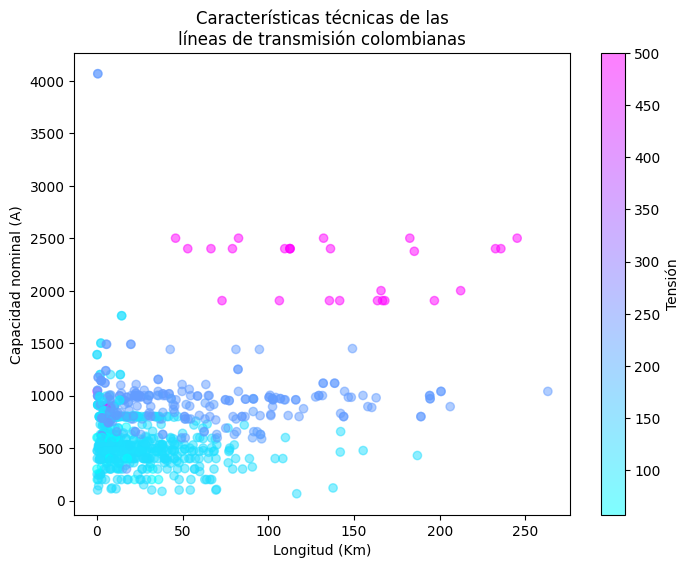

In [34]:
plt.figure(figsize=(8,6))
plt.scatter(DF['LONGITUD'],DF['CAPACIDAD-N'],alpha=0.5,c=DF['TENSIÓN'],cmap=cm.cool)
cbar=plt.colorbar(label='Tensión')
plt.title('Características técnicas de las\nlíneas de transmisión colombianas')
plt.xlabel("Longitud (Km)")
plt.ylabel("Capacidad nominal (A)")

## 4.3. El problema del desbalance

¿Por qué razón no aparece ninguna regla que relacione las líneas de tensión alta? Es extraño, porque en la nube de puntos se distinguen muy bien.

La razón: son muy pocos casos y el *soporte* de las reglas es muy bajito.

Probemos ahora, con un umbral de soporte más bajo:

In [35]:
frequent_itemsets = apriori(DFT, min_support=0.01, use_colnames=True)
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(lambda x: len(x))
frequent_itemsets.describe()

,support,length
count,34.000000,34.000000
mean,0.203591,1.970588
std,0.213563,0.717119
min,0.010465,1.000000
25%,0.056977,1.250000
50%,0.081395,2.000000
75%,0.350872,2.000000
max,0.769767,3.000000


In [36]:
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.85)
rules["antecedents_length"] = rules["antecedents"].apply(lambda x: len(x))
rules["consequents_length"] = rules["consequents"].apply(lambda x: len(x))
rules.sort_values("confidence",ascending=False)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski,antecedents_length,consequents_length
15,"(LONGITUD_LARGA, CAPACIDAD-N_ALTO)",(TENSIÓN_ALTO),0.023256,0.033721,0.023256,1.000000,29.655172,1.0,0.022472,inf,0.989286,0.689655,1.000000,0.844828,2,1
13,"(LONGITUD_LARGA, TENSIÓN_MEDIO)",(CAPACIDAD-N_MEDIO),0.056977,0.517442,0.056977,1.000000,1.932584,1.0,0.027495,inf,0.511714,0.110112,1.000000,0.555056,2,1
14,"(TENSIÓN_ALTO, LONGITUD_LARGA)",(CAPACIDAD-N_ALTO),0.023256,0.034884,0.023256,1.000000,28.666667,1.0,0.022445,inf,0.988095,0.666667,1.000000,0.833333,2,1
6,"(CAPACIDAD-N_BAJO, LONGITUD_CORTA)",(TENSIÓN_BAJO),0.377907,0.689535,0.375581,0.993846,1.441328,1.0,0.115001,50.450581,0.492202,0.542857,0.980179,0.769267,2,1
1,(CAPACIDAD-N_BAJO),(TENSIÓN_BAJO),0.447674,0.689535,0.440698,0.984416,1.427652,1.0,0.132011,19.921512,0.542341,0.632721,0.949803,0.811769,1,1
9,"(TENSIÓN_MEDIO, LONGITUD_CORTA)",(CAPACIDAD-N_MEDIO),0.153488,0.517442,0.148837,0.969697,1.874021,1.0,0.069416,15.924419,0.550953,0.285078,0.937203,0.628669,2,1
2,(TENSIÓN_MEDIO),(CAPACIDAD-N_MEDIO),0.276744,0.517442,0.267442,0.966387,1.867623,1.0,0.124243,14.356105,0.642318,0.507726,0.930343,0.741620,1,1
12,"(CAPACIDAD-N_MEDIO, LONGITUD_LARGA)",(TENSIÓN_MEDIO),0.059302,0.276744,0.056977,0.960784,3.471742,1.0,0.040565,18.443023,0.756843,0.204167,0.945779,0.583333,2,1
7,"(CAPACIDAD-N_MEDIO, TENSIÓN_BAJO)",(LONGITUD_CORTA),0.246512,0.769767,0.233721,0.948113,1.231688,1.0,0.043964,4.437209,0.249647,0.298663,0.774633,0.625869,2,1
11,"(LONGITUD_MEDIA, TENSIÓN_MEDIO)",(CAPACIDAD-N_MEDIO),0.066279,0.517442,0.061628,0.929825,1.796964,1.0,0.027332,6.876453,0.474988,0.118040,0.854576,0.524463,2,1


## 4.3. Efecto del umbral del soporte

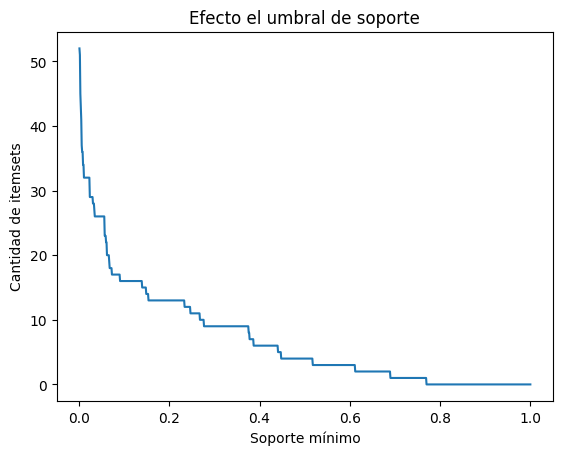

In [37]:
umbrales=np.linspace(0.001,1,1000)
itemsets=[]
for umbral in umbrales:
    frequent_itemsets = apriori(DFT, min_support=umbral, use_colnames=True)
    frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(lambda x: len(x))
    itemsets.append(frequent_itemsets['length'].count())
    
plt.plot(umbrales,itemsets)
plt.xlabel('Soporte mínimo')
plt.ylabel('Cantidad de itemsets')
plt.title('Efecto el umbral de soporte')
plt.show()

# 5. Ejercicio sugerido

Explore las reglas de asociación que puedan surgir al relacionar las dos estrategias de agrupamiento, qee están en las columnas **CLUSTER** y **CLUSTER2**. Por ejemplo, a partir de la siguiente tabla transaccional:

In [57]:
DF.groupby('CLUSTER')['TENSIÓN'].mean()


CLUSTER
0    227.184874
1    110.584317
2    500.000000
Name: TENSIÓN, dtype: float64

In [59]:
DF

,OPERADOR,LÍNEA,TENSIÓN,LONGITUD,CAPACIDAD-N,CAPACIDAD-T,CAPACIDAD-E,R1,X1,B1,...,TIPO,CALIBRE,FECHA,OBSERVACIONES,COMPARTIDO,ACUERDO,EDAD,NIVEL,CLUSTER,CLUSTER2
0,ACUEDUCTO METROPOLITANO DE BUCARAMANGA S A E S P,BOSCONIA TBOSCONIA 1 115 KV,115.0,1.04,140.0,140.0,140.0,1.3750,0.5000,3.4375,...,NaN,0.00,1984-09-01,NaN,No,NaN,14914,Baja,1,0
1,AIR- E S.A.S. E.S.P.,BARANOA MALAMBO 1 110 kV,110.0,17.70,530.0,580.0,580.0,0.1194,0.4952,3.3400,...,AAAC,559.5,1985-01-01,NaN,No,NaN,14792,Baja,1,0
2,AIR- E S.A.S. E.S.P.,CARACOLI CORDIALIDAD 1 110 kV,110.0,14.20,500.0,580.0,570.0,0.1191,0.4718,3.5600,...,NaN,0.00,2019-02-25,NaN,No,NaN,2319,Baja,1,0
3,AIR- E S.A.S. E.S.P.,CARACOLI MALAMBO 2 110 kV,110.0,9.50,500.0,580.0,570.0,0.1191,0.4718,3.5600,...,NaN,0.00,2019-01-27,NaN,No,NaN,2348,Baja,1,0
4,AIR- E S.A.S. E.S.P.,CARACOLI SILENCIO 1 110 kV,110.0,12.50,691.0,706.0,706.0,0.0736,0.4552,3.6814,...,NaN,0.00,2019-02-25,NaN,No,NaN,2319,Baja,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
855,TRANSELCA S.A. E.S.P.,TERMOCANDELARIA TERNERA 1 220 kV,220.0,3.12,787.0,813.0,790.0,0.0896,0.4955,3.3608,...,NaN,0.00,2000-05-24,NaN,No,NaN,9170,Media,0,0
856,TRANSELCA S.A. E.S.P.,TERMOCANDELARIA TERNERA 2 220 kV,220.0,3.12,787.0,813.0,790.0,0.0896,0.4955,3.3608,...,NaN,0.00,2000-06-24,NaN,No,NaN,9139,Media,0,0
857,TRANSELCA S.A. E.S.P.,TERMOFLORES NUEVA BARRANQUILLA 1 220 kV,220.0,7.40,840.0,890.0,890.0,0.0885,0.4658,3.5795,...,NaN,0.00,1999-05-14,NaN,No,NaN,9546,Media,0,0
858,TRANSELCA S.A. E.S.P.,TERMOFLORES NUEVA BARRANQUILLA 2 220 kV,220.0,7.40,840.0,890.0,890.0,0.0885,0.4658,3.5795,...,NaN,0.00,1999-06-02,NaN,No,NaN,9527,Media,0,0


In [68]:
DF.groupby('CLUSTER2')[['R0','X0','B0','R1','X1','B1']].mean().mean(axis=1)

CLUSTER2
0     1.341438
1    35.002800
2     8.722133
dtype: float64

In [69]:
columnas={'CLUSTER'    :[['BAJO',0.5,1.5] ,['MEDIO',-0.5,0.5],  ['ALTO',1.5,2.5]],
          'CLUSTER2'   :[['CORTA',-0.5,0.5],['MEDIA',1.5,2.5],['LARGA',0.5,1.5]]}

DFT2=DFtransacciones(DF,columnas)
DFT2.head()

,CLUSTER_BAJO,CLUSTER_MEDIO,CLUSTER_ALTO,CLUSTER2_CORTA,CLUSTER2_MEDIA,CLUSTER2_LARGA
0,True,False,False,True,False,False
1,True,False,False,True,False,False
2,True,False,False,True,False,False
3,True,False,False,True,False,False
4,True,False,False,True,False,False


Definimos el umbral de soporte en 0.01.

In [71]:
frequent_itemsets = apriori(DFT2, min_support=0.01, use_colnames=True)
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(lambda x: len(x))
frequent_itemsets.describe()

,support,length
count,8.000000,8.000000
mean,0.373110,1.375000
std,0.369102,0.517549
min,0.010465,1.000000
25%,0.033721,1.000000
50%,0.274419,1.000000
75%,0.683430,2.000000
max,0.987209,2.000000


In [72]:
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.85)
rules["antecedents_length"] = rules["antecedents"].apply(lambda x: len(x))
rules["consequents_length"] = rules["consequents"].apply(lambda x: len(x))
rules.sort_values("confidence",ascending=False)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski,antecedents_length,consequents_length
2,(CLUSTER_ALTO),(CLUSTER2_CORTA),0.033721,0.987209,0.033721,1.000000,1.012956,1.0,0.000431,inf,0.013237,0.034158,1.000000,0.517079,1,1
0,(CLUSTER_BAJO),(CLUSTER2_CORTA),0.689535,0.987209,0.681395,0.988196,1.000999,1.0,0.000680,1.083555,0.003215,0.684579,0.077112,0.839210,1,1
1,(CLUSTER_MEDIO),(CLUSTER2_CORTA),0.276744,0.987209,0.272093,0.983193,0.995932,1.0,-0.001111,0.761047,-0.005616,0.274326,-0.313980,0.629406,1,1


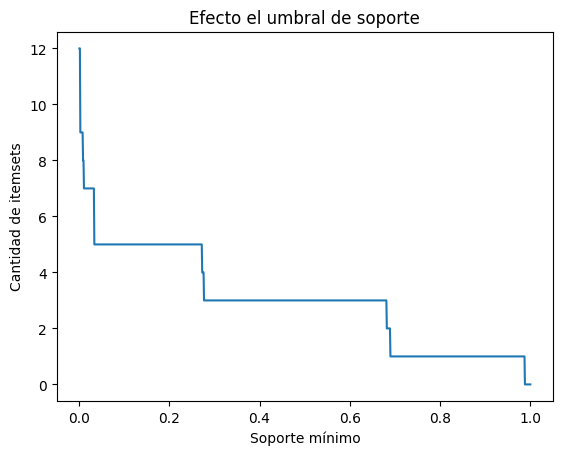

In [73]:
umbrales=np.linspace(0.001,1,1000)
itemsets=[]
for umbral in umbrales:
    frequent_itemsets = apriori(DFT2, min_support=umbral, use_colnames=True)
    frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(lambda x: len(x))
    itemsets.append(frequent_itemsets['length'].count())
    
plt.plot(umbrales,itemsets)
plt.xlabel('Soporte mínimo')
plt.ylabel('Cantidad de itemsets')
plt.title('Efecto el umbral de soporte')
plt.show()

El cluster 2 tiene mucho desbalance, por lo que no importa el nivel de tensión, lo va a asociar a una capacidad corta.